In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [23]:
np.random.seed(42)
data = {
    'Customer ID': np.arange(1, 101),
    'Age': np.random.randint(18, 65, size=100),
    'average spend' : np.random.uniform(5, 50, size=100),
    'Visit per week': np.random.randint(1,10, size= 100),
    'Promotion Interest' : np.random.randint(0, 2, size = 100)


}
df = pd.DataFrame(data)
df.head()

,Customer ID,Age,average spend,Visit per week,Promotion Interest
0,1,56,18.206968,3,1
1,2,46,5.633592,3,1
2,3,32,13.947908,4,0
3,4,60,37.010388,7,1
4,5,25,40.557899,4,0


**Apply Kmean cluster to segment customers** : Elbow method

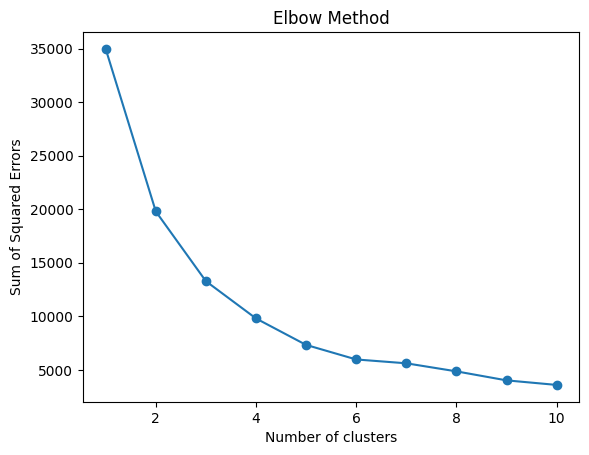

In [24]:
x = df[['Age', 'average spend', 'Visit per week', 'Promotion Interest']]
sse = []
k_range = range(1, 11)
for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(x)
  sse.append(kmeans.inertia_)

plt.plot(k_range, sse, marker ='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of Squared Errors')
plt.show()

In [25]:
kmeans = KMeans(n_clusters=3, random_state = 42)
df['Cluster'] = kmeans.fit_predict(x)
#rename cluster
cluster_name = {
    0: 'Daily',
    1: 'Weekly',
    2: 'Monthly'
}
df['Cluster Group'] = df['Cluster'].map(cluster_name)
df.head()


,Customer ID,Age,average spend,Visit per week,Promotion Interest,Cluster,Cluster Group
0,1,56,18.206968,3,1,2,Monthly
1,2,46,5.633592,3,1,2,Monthly
2,3,32,13.947908,4,0,2,Monthly
3,4,60,37.010388,7,1,0,Daily
4,5,25,40.557899,4,0,1,Weekly


Visualize the cluster

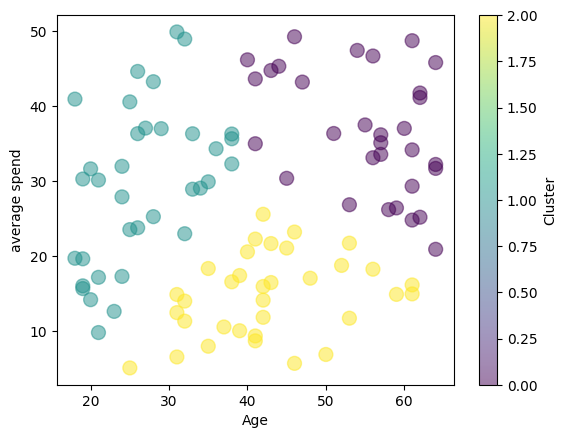

In [26]:
plt.scatter(df['Age'], df['average spend'], c=df['Cluster'], cmap='viridis', marker='o', s=100, alpha=0.5)
plt.xlabel('Age')
plt.ylabel('average spend')
plt.colorbar(label='Cluster')
plt.show()

In [27]:
print(f"silhoutte score{silhouette_score(x, df['Cluster']) :.2f}")

silhoutte score0.38


Save kmean for future prediction

In [28]:
import pickle
pickle.dump(kmeans, open('kmeans.pkl', 'wb'))
kmeans = pickle.load(open('kmeans.pkl', 'rb'))

**Predict new customer**

In [29]:
def clustering(age, average_spend, visit_per_week, promotion_interest):
  new_customer = np.array([[age, average_spend, visit_per_week, promotion_interest]])
  predicted_cluster = kmeans.predict(new_customer)

  if predicted_cluster[0] == 0:
    cluster_group = 'Daily'

  elif predicted_cluster[0] == 1:
    cluster_group = 'Weekly'

  else:
    cluster_group = 'Monthly'

  return cluster_group


In [30]:
predicted_cluster = clustering(30, 30, 3, 5)
print(predicted_cluster)


Weekly


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [40]:
predicted_cluster= clustering(30, 1, 1, 3)
print(predicted_cluster)

Monthly


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
